# Cascading Accessibility Risk in Urban Networks
## Graph Policy Learning for Resilient Public-Service Planning

<p align="center">
  <img src="https://img.shields.io/badge/Python-3.x-3776AB?logo=python&logoColor=white" alt="Python">
  <img src="https://img.shields.io/badge/PyTorch-2.12.0%2Bcu126-EE4C2C?logo=pytorch&logoColor=white" alt="PyTorch">
  <img src="https://img.shields.io/badge/CUDA-enabled-76B900?logo=nvidia&logoColor=white" alt="CUDA">
  <img src="https://img.shields.io/badge/Reproducibility-v1.1.0--B-2F6F9F" alt="Reproducibility">
  <img src="https://img.shields.io/badge/Study%20area-MEL%2C%20France-555555" alt="Study area">
</p>

This repository contains the public reproducibility pipeline for the paper:

> **Cascading Accessibility Risk in Urban Networks: Graph Policy Learning for Resilient Public-Service Planning**

The code implements the empirical workflow linking potential accessibility, disruption trajectories, sequential public restoration, and graph based policy learning for **Métropole Européenne de Lille (MEL), France**.

The canonical public entry point is the `reproduce` stage. It checks or reconstructs the required public-data inputs, validates the frozen disruption design, trains the graph policies and controlled ablations, performs exact held-out evaluation, regenerates the publication source data, figures, and tables, and assembles a checksummed reproducibility bundle.

---

## 1. Repository scope

The pipeline is organized around the empirical counterparts of the manuscript's analytical framework:

- **Urban system and Cascading Accessibility Risk (CAR):** spatial units, essential health-service opportunities, road-network accessibility, disruption trajectories, and cumulative accessibility consequences.
- **Sequential public intervention:** capacity restoration under a pathwise budget and a common empirical action correspondence.
- **Graph policy learning:** a parameterized graph policy trained under a frozen numerical protocol and compared with benchmark and ablation specifications.
- **Held-out evaluation:** trajectory-separated ordinary and structural holdouts, exact full-network outcome evaluation, paired inference, and publication-ready outputs.

---

In [1]:
# Libraries
import pandas as pd
import numpy as np

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

from shapely import wkt
from matplotlib.colors import PowerNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

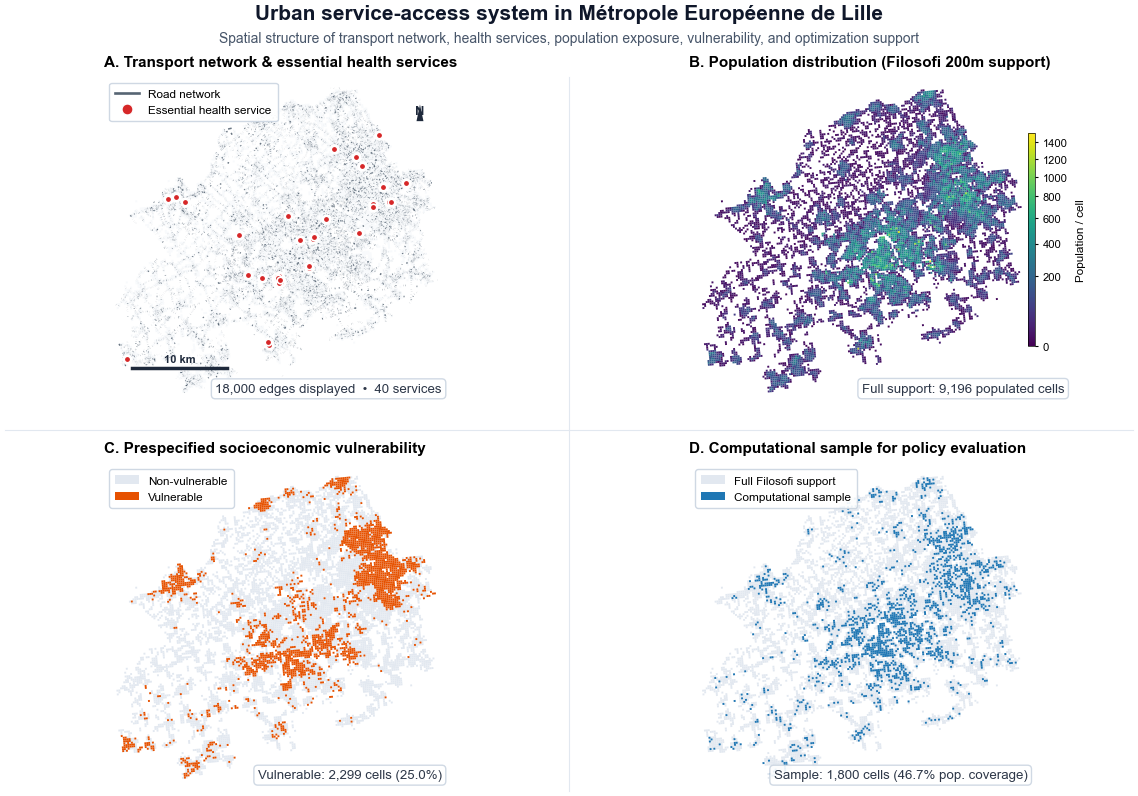

In [2]:
# =============================================================================
# Figure 1
# =============================================================================

data_fig1_zones = pd.read_csv("C:/Users/fredy/Downloads/CEUS_LILLE_DATA/figure_data/q1pp_v1_1_0/fig1_zones.csv")

data_fig1_services = pd.read_csv("C:/Users/fredy/Downloads/CEUS_LILLE_DATA/figure_data/q1pp_v1_1_0/fig1_services.csv")

data_fig1_network = pd.read_csv("C:/Users/fredy/Downloads/CEUS_LILLE_DATA/figure_data/q1pp_v1_1_0/fig1_network_edges.csv")

# =============================================================================
# RECONSTRUCT GEOMETRIES
# =============================================================================

data_fig1_zones["geometry"] = data_fig1_zones["geometry_wkt"].map(wkt.loads)
data_fig1_services["geometry"] = data_fig1_services["geometry_wkt"].map(wkt.loads)
data_fig1_network["geometry"] = data_fig1_network["geometry_wkt"].map(wkt.loads)

zones = gpd.GeoDataFrame(
    data_fig1_zones.drop(columns="geometry_wkt"),
    geometry="geometry",
    crs="EPSG:2154",
)

services = gpd.GeoDataFrame(
    data_fig1_services.drop(columns="geometry_wkt"),
    geometry="geometry",
    crs="EPSG:2154",
)

network = gpd.GeoDataFrame(
    data_fig1_network.drop(columns="geometry_wkt"),
    geometry="geometry",
    crs="EPSG:2154",
)

# =============================================================================
# DATA AUDIT & COMPUTATIONS
# =============================================================================

zones["is_vulnerable"] = zones["is_vulnerable"].astype(bool)
zones["in_model_sample"] = zones["in_model_sample"].astype(bool)

population_full = zones["P_i"].sum()
population_model = zones.loc[zones["in_model_sample"], "P_i"].sum()
population_coverage = 100 * population_model / population_full
vulnerability_share = 100 * zones["is_vulnerable"].mean()

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 9.5,
        "legend.fontsize": 8.5,
        "figure.titlesize": 15.0,
        "axes.linewidth": 0.8,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
    }
)

ROAD_COLOR = "#2C3E50"
SERVICE_COLOR = "#D62728"

NONVUL_COLOR = "#E2E8F0"
VUL_COLOR = "#E65100"

SUPPORT_COLOR = "#E2E8F0"
SAMPLE_COLOR = "#1F77B4"

TEXT_GREY = "#2D3748"
BG_LIGHT_BOX = "#FFFFFF"

# EXTENT & BOUNDS

xmin, ymin, xmax, ymax = zones.total_bounds
dx = xmax - xmin
dy = ymax - ymin

pad_x = 0.04 * dx
pad_y = 0.04 * dy

xlim = (xmin - pad_x, xmax + pad_x)
ylim = (ymin - pad_y, ymax + pad_y)

# =============================================================================
# FIGURE ARCHITECTURE
# =============================================================================

fig = plt.figure(figsize=(12.0, 8.6), facecolor="white")

gs = fig.add_gridspec(
    2,
    2,
    left=0.03,
    right=0.97,
    bottom=0.05,
    top=0.88,
    wspace=0.08,
    hspace=0.18,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])

# =============================================================================
# PANEL A: NETWORK & SERVICES
# =============================================================================

zones.plot(ax=axA, color="#F8FAFC", edgecolor="none", zorder=0.4, rasterized=True)

network.plot(
    ax=axA,
    color=ROAD_COLOR,
    linewidth=1.12,
    alpha=0.7,
    zorder=1,
    rasterized=True,
)

services.plot(
    ax=axA,
    color="white",
    edgecolor="white",
    markersize=55,
    linewidth=0,
    zorder=3,
)

services.plot(
    ax=axA,
    color=SERVICE_COLOR,
    edgecolor="white",
    linewidth=1.2,
    markersize=22,
    zorder=4,
)

axA.set_title(
    "A. Transport network & essential health services",
    loc="left",
    fontweight="bold",
    pad=8,
)

axA.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=ROAD_COLOR,
            linewidth=1.9,
            alpha=0.8,
            label="Road network",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=SERVICE_COLOR,
            markeredgecolor="white",
            markeredgewidth=0.8,
            markersize=7.8,
            label="Essential health service",
        ),
    ],
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    facecolor=BG_LIGHT_BOX,
    edgecolor="#CBD5E1",
    borderpad=0.5,
)

axA.text(
    0.98,
    0.03,
    f"{len(network):,} edges displayed  •  {len(services)} services",
    transform=axA.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    color=TEXT_GREY,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor=BG_LIGHT_BOX,
        edgecolor="#CBD5E1",
        alpha=0.9,
    ),
)

# =============================================================================
# PANEL B: POPULATION EXPOSURE
# =============================================================================

pop_norm = PowerNorm(gamma=0.55, vmin=0, vmax=zones["P_i"].max())


zones.plot(ax=axB, color="#F1F5F9", edgecolor="none", zorder=0.3, rasterized=True)

zones.plot(
    column="P_i",
    ax=axB,
    cmap="viridis",
    norm=pop_norm,
    linewidth=0.3,
    rasterized=True,
    zorder=1,
)

axB.set_title(
    "B. Population distribution (Filosofi 200m support)",
    loc="left",
    fontweight="bold",
    pad=8,
)

cax = axB.inset_axes([0.98, 0.18, 0.022, 0.65])
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=pop_norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.ax.tick_params(labelsize=8, length=2)
cbar.outline.set_linewidth(0.5)
cbar.set_label("Population / cell", fontsize=8.5, labelpad=6)

axB.text(
    0.5,
    0.03,
    f"Full support: {len(zones):,} populated cells",
    transform=axB.transAxes,
    ha="left",
    va="bottom",
    fontsize=9.5,
    color=TEXT_GREY,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor=BG_LIGHT_BOX,
        edgecolor="#CBD5E1",
        alpha=0.9,
    ),
)

# =============================================================================
# PANEL C: SOCIOECONOMIC VULNERABILITY
# =============================================================================

zones.loc[~zones["is_vulnerable"]].plot(ax=axC, color=NONVUL_COLOR, linewidth=0.4, rasterized=True, zorder=1)

zones.loc[zones["is_vulnerable"]].plot(ax=axC, color=VUL_COLOR, linewidth=0.4, rasterized=True, zorder=2)

axC.set_title(
    "C. Prespecified socioeconomic vulnerability",
    loc="left",
    fontweight="bold",
    pad=8,
)

axC.legend(
    handles=[
        Patch(facecolor=NONVUL_COLOR, edgecolor="none", label="Non-vulnerable"),
        Patch(facecolor=VUL_COLOR, edgecolor="none", label="Vulnerable"),
    ],
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    facecolor=BG_LIGHT_BOX,
    edgecolor="#CBD5E1",
    borderpad=0.5,
)

axC.text(
    0.98,
    0.03,
    f"Vulnerable: {zones['is_vulnerable'].sum():,} cells ({vulnerability_share:.1f}%)",
    transform=axC.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    color=TEXT_GREY,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor=BG_LIGHT_BOX,
        edgecolor="#CBD5E1",
        alpha=0.9,
    ),
)

# =============================================================================
# PANEL D: COMPUTATIONAL SAMPLE
# =============================================================================

zones.plot(ax=axD, color=SUPPORT_COLOR, linewidth=0.4, rasterized=True, zorder=1)

zones.loc[zones["in_model_sample"]].plot(ax=axD, color=SAMPLE_COLOR, linewidth=0.4, rasterized=True, zorder=2)

axD.set_title(
    "D. Computational sample for policy evaluation",
    loc="left",
    fontweight="bold",
    pad=8,
)

axD.legend(
    handles=[
        Patch(
            facecolor=SUPPORT_COLOR,
            edgecolor="none",
            label="Full Filosofi support",
        ),
        Patch(
            facecolor=SAMPLE_COLOR,
            edgecolor="none",
            label="Computational sample",
        ),
    ],
    loc="upper left",
    frameon=True,
    framealpha=0.92,
    facecolor=BG_LIGHT_BOX,
    edgecolor="#CBD5E1",
    borderpad=0.5,
)

axD.text(
    0.98,
    0.03,
    f"Sample: {zones['in_model_sample'].sum():,} cells ({population_coverage:.1f}% pop. coverage)",
    transform=axD.transAxes,
    ha="right",
    va="bottom",
    fontsize=9.5,
    color=TEXT_GREY,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor=BG_LIGHT_BOX,
        edgecolor="#CBD5E1",
        alpha=0.9,
    ),
)

# =============================================================================
# COMMON FORMATTING, SCALEBAR & NORTH ARROW
# =============================================================================

for ax in [axA, axB, axC, axD]:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


scalebar_len = 10000
sb_x = xmin + 0.05 * dx
sb_y = ymin + 0.08 * dy

axA.plot(
    [sb_x, sb_x + scalebar_len],
    [sb_y, sb_y],
    color="#1E293B",
    linewidth=2.5,
    zorder=10,
)
axA.text(
    sb_x + scalebar_len / 2,
    sb_y + 0.015 * dy,
    "10 km",
    ha="center",
    va="bottom",
    fontsize=8,
    fontweight="bold",
    color="#1E293B",
    zorder=10,
)

arrow_x = xmax - 0.05 * dx
arrow_y = ymax - 0.05 * dy
axA.annotate(
    "N",
    xy=(arrow_x, arrow_y),
    xytext=(arrow_x, arrow_y - 0.04 * dy),
    arrowprops=dict(facecolor="#1E293B", edgecolor="none", width=1.5, headwidth=5),
    ha="center",
    va="bottom",
    fontsize=9.3,
    fontweight="bold",
    color="#1E293B",
    zorder=10,
)

fig.suptitle(
    "Urban service-access system in Métropole Européenne de Lille",
    x=0.5,
    y=0.965,
    fontsize=15,
    fontweight="bold",
    color="#0F172A",
)

fig.text(
    0.5,
    0.925,
    "Spatial structure of transport network, health services, population exposure, vulnerability, and optimization support",
    ha="center",
    va="center",
    fontsize=10,
    color="#475569",
)

fig.add_artist(
    mpl.lines.Line2D(
        [0.5, 0.5],
        [0.05, 0.88],
        transform=fig.transFigure,
        color="#E2E8F0",
        linewidth=0.8,
        zorder=0,
    )
)

fig.add_artist(
    mpl.lines.Line2D(
        [0.03, 0.97],
        [0.47, 0.47],
        transform=fig.transFigure,
        color="#E2E8F0",
        linewidth=0.8,
        zorder=0,
    )
)

plt.show()


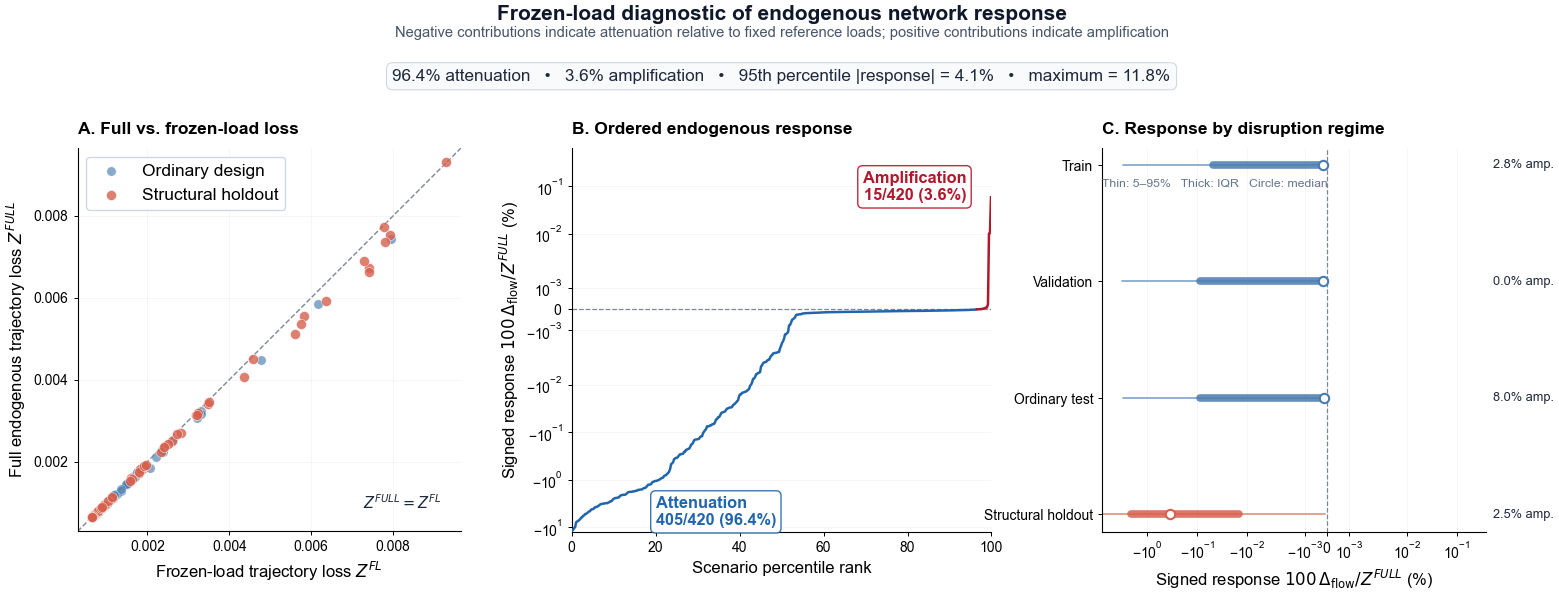

In [3]:
# =============================================================================
# Figure 2
# =============================================================================


data_fig2 = pd.read_csv("C:/Users/fredy/Downloads/CEUS_LILLE_DATA/figure_data/q1pp_v1_1_0/fig2_cascade_diagnostic.csv")

d = data_fig2.copy()

d["response_pct"] = 100.0 * d["Delta_flow"] / d["Z_FULL"]

n_total = len(d)
n_attenuation = int((d["Delta_flow"] < 0).sum())
n_amplification = int((d["Delta_flow"] > 0).sum())

attenuation_share = 100 * n_attenuation / n_total
amplification_share = 100 * n_amplification / n_total

p95_abs_share = np.quantile(np.abs(d["response_pct"]), 0.95)
max_abs_share = np.max(np.abs(d["response_pct"]))


mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 12.5,
        "axes.titlesize": 12.5,
        "axes.labelsize": 12.,
        "legend.fontsize": 12.5,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 10.,
        "ytick.labelsize": 10.,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05,
    }
)

# COLOR SYSTEM

ATTENUATION_COLOR = "#2166AC"
AMPLIFICATION_COLOR = "#B2182B"

ORDINARY_COLOR = "#4A7BB0"
STRUCTURAL_COLOR = "#D6604D"

REFERENCE_COLOR = "#475569"
TEXT_COLOR = "#1E293B"

# =============================================================================
# FIGURE LAYOUT
# =============================================================================

fig = plt.figure(figsize=(16.0, 6.2), facecolor="white")

# 'top=0.74' réserve l'espace nécessaire pour le triple en-tête
gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.05, 1.15, 1.05],
    left=0.06,
    right=0.94,
    bottom=0.12,
    top=0.74,
    wspace=0.28,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])

# =============================================================================
# PANEL A: FULL vs FROZEN-LOAD LOSS
# =============================================================================

ordinary = ~d["structural"].astype(bool)
structural = d["structural"].astype(bool)

axA.scatter(
    d.loc[ordinary, "Z_FL"],
    d.loc[ordinary, "Z_FULL"],
    s=45,
    color=ORDINARY_COLOR,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.3,
    label="Ordinary design",
    zorder=2,
)

axA.scatter(
    d.loc[structural, "Z_FL"],
    d.loc[structural, "Z_FULL"],
    s=52,
    color=STRUCTURAL_COLOR,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.4,
    label="Structural holdout",
    zorder=3,
)

xy_min = min(d["Z_FL"].min(), d["Z_FULL"].min())
xy_max = max(d["Z_FL"].max(), d["Z_FULL"].max())
pad = 0.04 * (xy_max - xy_min)

axA.plot(
    [xy_min - pad, xy_max + pad],
    [xy_min - pad, xy_max + pad],
    linestyle="--",
    color=REFERENCE_COLOR,
    linewidth=1.0,
    alpha=0.7,
    zorder=1,
)

axA.set_xlim(xy_min - pad, xy_max + pad)
axA.set_ylim(xy_min - pad, xy_max + pad)
axA.set_aspect("equal", adjustable="box")

axA.set_xlabel(r"Frozen-load trajectory loss $Z^{FL}$")
axA.set_ylabel(r"Full endogenous trajectory loss $Z^{FULL}$")
axA.set_title("A. Full vs. frozen-load loss", loc="left", fontweight="bold", pad=10)

axA.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=0.92,
    edgecolor="#CBD5E1",
)

axA.text(
    0.95,
    0.05,
    r"$Z^{FULL}=Z^{FL}$",
    transform=axA.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.5,
    color=TEXT_COLOR,
)

axA.grid(True, alpha=0.15, linewidth=0.5)

# =============================================================================
# PANEL B: ORDERED ENDOGENOUS RESPONSE
# =============================================================================

ordered = d.sort_values("response_pct").reset_index(drop=True)
ordered["percentile"] = (100 * (np.arange(len(ordered)) + 0.5) / len(ordered))

neg = ordered["response_pct"] < 0
pos = ordered["response_pct"] > 0

axB.plot(
    ordered.loc[neg, "percentile"],
    ordered.loc[neg, "response_pct"],
    color=ATTENUATION_COLOR,
    linewidth=1.8,
    zorder=3,
)

axB.plot(
    ordered.loc[pos, "percentile"],
    ordered.loc[pos, "response_pct"],
    color=AMPLIFICATION_COLOR,
    linewidth=1.8,
    zorder=4,
)

axB.axhline(0, color=REFERENCE_COLOR, linestyle="--", linewidth=0.9, alpha=0.7)

axB.set_yscale("symlog", linthresh=0.002, linscale=0.8, base=10)
axB.set_xlim(0, 100)

axB.set_xlabel("Scenario percentile rank")
axB.set_ylabel(r"Signed response $100\,\Delta_{\mathrm{flow}}/Z^{FULL}$ (%)")
axB.set_title("B. Ordered endogenous response", loc="left", fontweight="bold", pad=10)

axB.grid(axis="y", alpha=0.15, linewidth=0.5)

axB.text(
    0.2,
    0.01,
    f"Attenuation\n{n_attenuation}/{n_total} ({attenuation_share:.1f}%)",
    transform=axB.transAxes,
    ha="left",
    va="bottom",
    color=ATTENUATION_COLOR,
    fontsize=11.8,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor=ATTENUATION_COLOR,
        alpha=0.9,
    ),
)

axB.text(
    0.94,
    0.94,
    f"Amplification\n{n_amplification}/{n_total} ({amplification_share:.1f}%)",
    transform=axB.transAxes,
    ha="right",
    va="top",
    color=AMPLIFICATION_COLOR,
    fontsize=11.8,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor=AMPLIFICATION_COLOR,
        alpha=0.9,
    ),
)

# =============================================================================
# PANEL C: RESPONSE BY DISRUPTION REGIME
# =============================================================================

regime_order = ["train", "validation", "test", "test_structural"]
regime_labels = ["Train", "Validation", "Ordinary test", "Structural holdout"]
ypos = np.arange(len(regime_order))[::-1]

for i, split_name in enumerate(regime_order):
    g = d.loc[d["split"] == split_name, "response_pct"].dropna()

    q05, q25, q50, q75, q95 = np.quantile(g, [0.05, 0.25, 0.50, 0.75, 0.95])
    y = ypos[i]

    color = (
        STRUCTURAL_COLOR
        if split_name == "test_structural"
        else ORDINARY_COLOR
    )

    # 5–95% Range
    axC.plot(
        [q05, q95],
        [y, y],
        color=color,
        linewidth=1.2,
        alpha=0.7,
        solid_capstyle="round",
        zorder=1,
    )

    # IQR (25–75%)
    axC.plot(
        [q25, q75],
        [y, y],
        color=color,
        linewidth=5.5,
        alpha=0.85,
        solid_capstyle="round",
        zorder=2,
    )

    # Median
    axC.scatter(
        q50,
        y,
        s=45,
        color="white",
        edgecolor=color,
        linewidth=1.5,
        zorder=4,
    )

    amp_share = (100 * (d.loc[d["split"] == split_name, "Delta_flow"] > 0).mean())

    axC.text(
        1.02,
        y,
        f"{amp_share:.1f}% amp.",
        transform=axC.get_yaxis_transform(),
        ha="left",
        va="center",
        fontsize=9.2,
        color=TEXT_COLOR,
    )

axC.axvline(0, color=REFERENCE_COLOR, linestyle="--", linewidth=0.9, alpha=0.7)
axC.set_xscale("symlog", linthresh=0.002, linscale=0.8, base=10)

axC.set_yticks(ypos)
axC.set_yticklabels(regime_labels)

axC.set_xlabel(r"Signed response $100\,\Delta_{\mathrm{flow}}/Z^{FULL}$ (%)")
axC.set_title("C. Response by disruption regime", loc="left", fontweight="bold", pad=10)

axC.grid(axis="x", alpha=0.15, linewidth=0.5)

axC.text(
    0.0,
    0.92,
    "Thin: 5–95%   Thick: IQR   Circle: median",
    transform=axC.transAxes,
    ha="left",
    va="top",
    fontsize=8.8,
    color="#64748B",
)

# =============================================================================
# AXES CLEANUP & FINISHING
# =============================================================================

for ax in [axA, axB, axC]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.7)

fig.suptitle(
    "Frozen-load diagnostic of endogenous network response",
    y=0.97,
    fontsize=15,
    fontweight="bold",
    color="#0F172A",
)

fig.text(
    0.5,
    0.925,
    "Negative contributions indicate attenuation relative to fixed reference loads; positive contributions indicate amplification",
    ha="center",
    va="center",
    fontsize=10.6,
    color="#475569",
)

fig.text(
    0.5,
    0.855,
    (
        f"{attenuation_share:.1f}% attenuation   •   "
        f"{amplification_share:.1f}% amplification   •   "
        f"95th percentile |response| = {p95_abs_share:.1f}%   •   "
        f"maximum = {max_abs_share:.1f}%"
    ),
    ha="center",
    va="center",
    fontsize=12.3,
    color=TEXT_COLOR,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="#F8FAFC",
        edgecolor="#CBD5E1",
        linewidth=0.7,
    ),
)

plt.show()


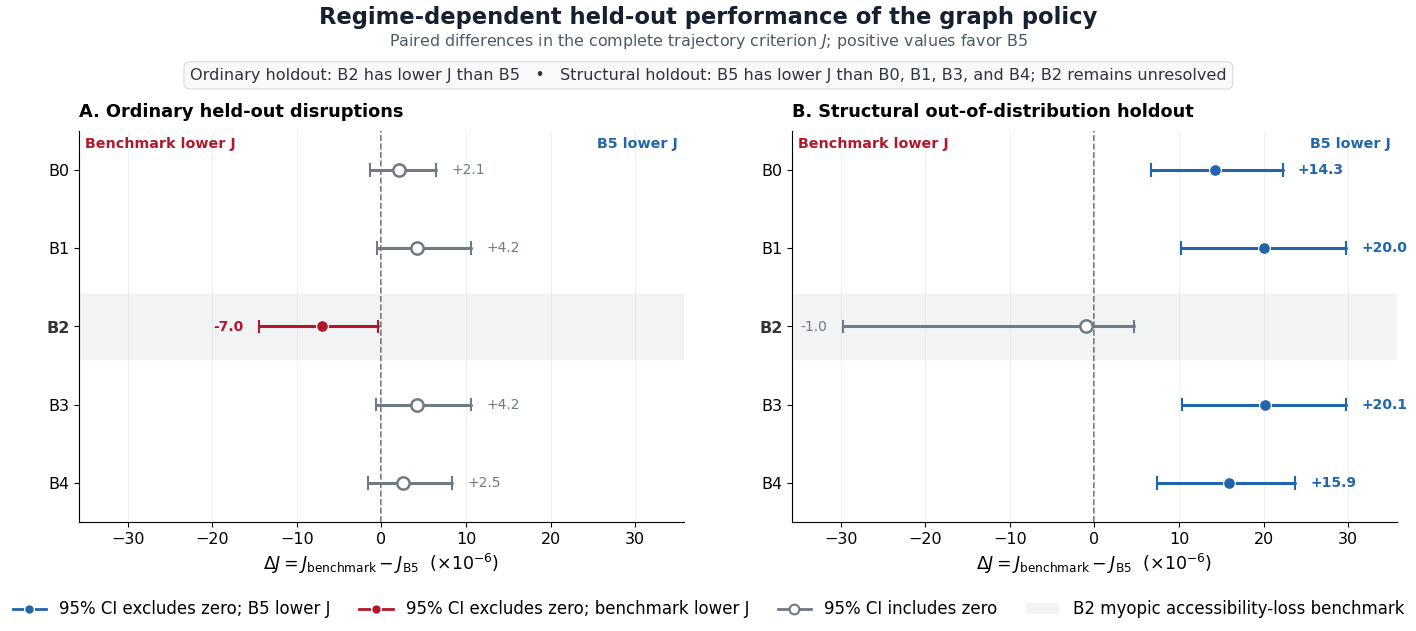

In [4]:
# =============================================================================
# Figure 3
# =============================================================================


data_fig3 = pd.read_csv("C:/Users/fredy/Downloads/CEUS_LILLE_DATA/figure_data/q1pp_v1_1_0/fig3_policy_regime_forest.csv")

d = data_fig3.copy()

# =============================================================================
# STRICT DATA AUDIT
# =============================================================================

required = [
    "split",
    "reference",
    "candidate",
    "delta_J",
    "J_ci_lo",
    "J_ci_hi",
]

missing = [c for c in required if c not in d.columns]

# =============================================================================
# SCIENTIFIC CLASSIFICATION
# =============================================================================

# Delta J = J_benchmark - J_B5
# Positive  -> B5 has lower J
# Negative  -> benchmark has lower J

d["resolved"] = ((d["J_ci_lo"] > 0) | (d["J_ci_hi"] < 0))

d["direction"] = np.select(
    [d["J_ci_hi"] < 0, d["J_ci_lo"] > 0,],
    ["benchmark", "B5"],
    default="unresolved"
)


scale = 1e6

d["delta_J_micro"] = scale * d["delta_J"]
d["J_ci_lo_micro"] = scale * d["J_ci_lo"]
d["J_ci_hi_micro"] = scale * d["J_ci_hi"]


# =============================================================================

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 13.,
    "axes.titlesize": 12.8,
    "axes.labelsize": 12.5,
    "legend.fontsize": 12.2,
    "figure.titlesize": 16.0,
    "xtick.labelsize": 11.5,
    "ytick.labelsize": 11.5,
    "axes.linewidth": 0.8,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.06,
})


# =============================================================================
# COLOR SYSTEM
# =============================================================================

B5_COLOR = "#2166AC"
BENCHMARK_COLOR = "#B2182B"
UNRESOLVED_COLOR = "#707A84"

ZERO_COLOR = "#2F3540"
GRID_COLOR = "#D9DEE3"

B2_BAND = "#F2F3F5"
TEXT_COLOR = "#30343B"


# =============================================================================
# COMMON X RANGE
# =============================================================================

global_min = d["J_ci_lo_micro"].min()
global_max = d["J_ci_hi_micro"].max()

span = global_max - global_min
pad = 0.10 * span

x_min = global_min - pad
x_max = global_max + pad

m = max(abs(x_min), abs(x_max))
x_min = -m
x_max = m


# =============================================================================
# FIGURE LAYOUT
# =============================================================================

fig = plt.figure(figsize=(14.8, 6.2), facecolor="white")

gs = fig.add_gridspec(
    1,
    2,
    left=0.075,
    right=0.965,
    bottom=0.16,
    top=0.79,
    wspace=0.18
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])


# =============================================================================
# PANELS
# =============================================================================

panels = [(axA, "test", "A. Ordinary held-out disruptions"),
          (axB, "test_structural", "B. Structural out-of-distribution holdout")]

benchmark_order = ["B0", "B1", "B2", "B3", "B4"]

for ax, split_name, panel_title in panels:
    g = (d.loc[d["split"] == split_name].set_index("reference").loc[benchmark_order].reset_index())
    y = np.arange(len(g))
    b2_index = benchmark_order.index("B2")
    ax.axhspan(b2_index - 0.42, b2_index + 0.42, color=B2_BAND, zorder=0)

    ax.axvline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.15, alpha=0.80, zorder=1)

    for i, row in g.iterrows():

        lo = row["J_ci_lo_micro"]
        est = row["delta_J_micro"]
        hi = row["J_ci_hi_micro"]

        if row["direction"] == "B5":
            color = B5_COLOR

        elif row["direction"] == "benchmark":
            color = BENCHMARK_COLOR

        else:
            color = UNRESOLVED_COLOR

        ax.plot(
            [lo, hi],
            [i, i],
            color=color,
            linewidth=2.2,
            solid_capstyle="round",
            zorder=3
        )

        cap = 0.075

        ax.plot(
            [lo, lo],
            [i - cap, i + cap],
            color=color,
            linewidth=1.5,
            zorder=3
        )

        ax.plot(
            [hi, hi],
            [i - cap, i + cap],
            color=color,
            linewidth=1.5,
            zorder=3
        )

        if row["resolved"]:

            ax.scatter(
                est,
                i,
                s=72,
                color=color,
                edgecolor="white",
                linewidth=0.8,
                zorder=5
            )

        else:

            ax.scatter(
                est,
                i,
                s=78,
                facecolor="white",
                edgecolor=color,
                linewidth=1.8,
                zorder=5
            )

        if est >= 0:
            text_x = hi + 0.025 * (x_max - x_min)
            ha = "left"

        else:
            text_x = lo - 0.025 * (x_max - x_min)
            ha = "right"

        ax.text(
            text_x,
            i,
            f"{est:+.1f}",
            ha=ha,
            va="center",
            fontsize=10.,
            color=color,
            fontweight="semibold" if row["resolved"] else "normal",
            zorder=6
        )

    # -------------------------------------------------------------
    # Axes
    # -------------------------------------------------------------

    ax.set_xlim(x_min, x_max)

    ax.set_ylim(len(g) - 0.5, -0.5)

    ax.set_yticks(y)

    ax.set_yticklabels(benchmark_order)

    ax.set_title(
        panel_title,
        loc="left",
        fontweight="semibold",
        pad=10
    )

    ax.set_xlabel(
        r"$\Delta J = J_{\mathrm{benchmark}} - J_{\mathrm{B5}}$"
        r"  $(\times 10^{-6})$"
    )

    ax.grid(
        axis="x",
        color=GRID_COLOR,
        linewidth=0.55,
        alpha=0.55,
        zorder=0
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8
    )


# =============================================================================
# DIRECT DIRECTION LABELS
# =============================================================================

for ax in [axA, axB]:
    ax.text(
        0.01,
        0.95,
        "Benchmark lower J",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10.3,
        color=BENCHMARK_COLOR,
        fontweight="semibold"
    )

    ax.text(
        0.99,
        0.95,
        "B5 lower J",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10.3,
        color=B5_COLOR,
        fontweight="semibold"
    )


# =============================================================================
# B2 LABEL EMPHASIS
# =============================================================================

for ax in [axA, axB]:

    labels = ax.get_yticklabels()

    for lab in labels:

        if lab.get_text() == "B2":

            lab.set_fontweight("bold")
            lab.set_color(TEXT_COLOR)

fig.suptitle(
    "Regime-dependent held-out performance of the graph policy",
    y=0.992,
    fontsize=16.3,
    fontweight="bold",
    color="#172033"
)

fig.text(
    0.5,
    0.935,
    (
        "Paired differences in the complete trajectory criterion "
        r"$J$; positive values favor B5"
    ),
    ha="center",
    va="center",
    fontsize=11.4,
    color="#4C596A"
)


# =============================================================================

fig.text(
    0.5,
    0.88,
    (
        "Ordinary holdout: B2 has lower J than B5   •   "
        "Structural holdout: B5 has lower J than B0, B1, B3, and B4; "
        "B2 remains unresolved"
    ),
    ha="center",
    va="center",
    fontsize=11.6,
    color=TEXT_COLOR,
    bbox=dict(
        boxstyle="round,pad=0.38",
        facecolor="#F7F9FB",
        edgecolor="#D6DCE3",
        linewidth=0.8
    )
)


# =============================================================================

legend_handles = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=B5_COLOR,
        markerfacecolor=B5_COLOR,
        markeredgecolor="white",
        linewidth=2,
        markersize=7,
        label="95% CI excludes zero; B5 lower J"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=BENCHMARK_COLOR,
        markerfacecolor=BENCHMARK_COLOR,
        markeredgecolor="white",
        linewidth=2,
        markersize=7,
        label="95% CI excludes zero; benchmark lower J"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="-",
        color=UNRESOLVED_COLOR,
        markerfacecolor="white",
        markeredgecolor=UNRESOLVED_COLOR,
        markeredgewidth=1.5,
        linewidth=2,
        markersize=7,
        label="95% CI includes zero"
    ),

    Patch(
        facecolor=B2_BAND,
        edgecolor="none",
        label="B2 myopic accessibility-loss benchmark"
    )
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False,
    fontsize=12.,
    handlelength=2.0,
    columnspacing=1.7
)

plt.show()


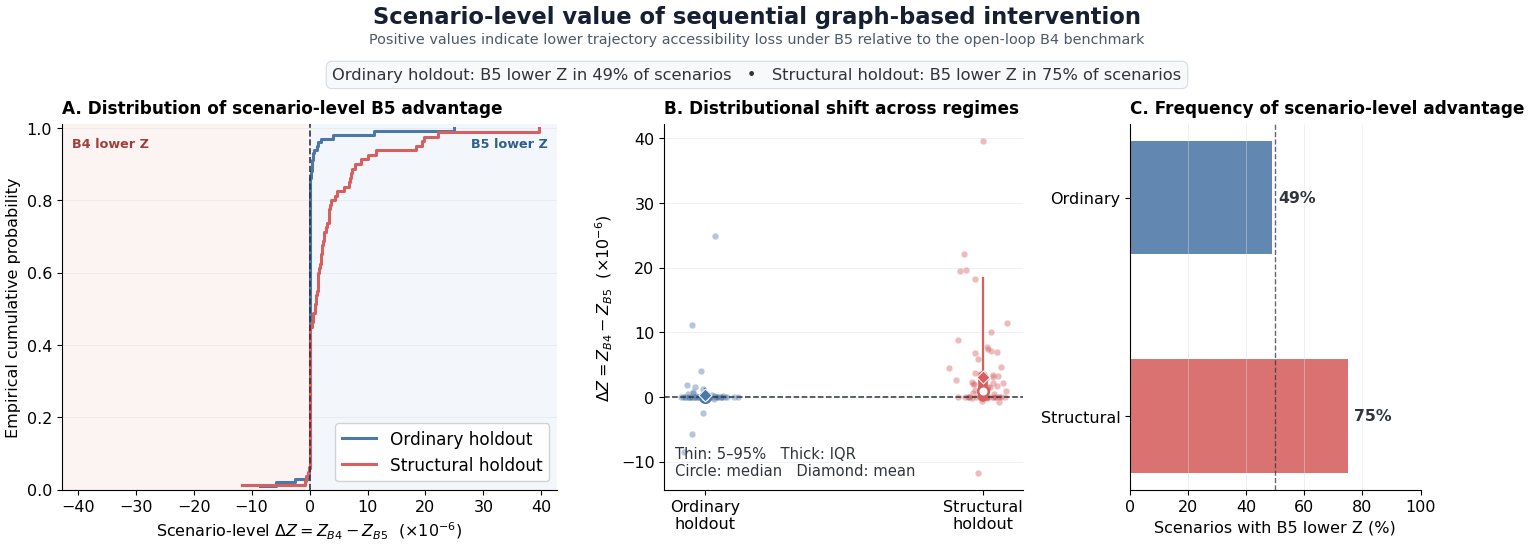

In [5]:
# =============================================================================
# Figure 4
# =============================================================================


data_fig4 = pd.read_csv("C:/Users/fredy/Downloads/CEUS_LILLE_DATA/figure_data/q1pp_v1_1_0/fig4_scenario_value_sequential_adaptation.csv")

d = data_fig4.copy()

required = ["split", "scenario_id", "delta_Z_B4_minus_B5", "delta_Q_B4_minus_B5"]

missing = [c for c in required if c not in d.columns]

d["delta_micro"] = 1e6 * d["delta_Z_B4_minus_B5"]


# SUMMARY STATISTICS

summary = (d.groupby("split")["delta_Z_B4_minus_B5"].agg(["count", "mean", "median", "min", "max"]))

summary["share_B5_lower"] = (d.groupby("split")["delta_Z_B4_minus_B5"].apply(lambda x: (x > 0).mean()))


# =============================================================================

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12.5,
    "axes.titlesize": 12.2,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 11.5,
    "ytick.labelsize": 11.5,
    "figure.titlesize": 16.0,
    "axes.linewidth": 0.8,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.06,
})

# COLORS

ORDINARY_COLOR = "#4C78A8"
STRUCTURAL_COLOR = "#D65F5F"

ZERO_COLOR = "#2F3540"
GRID_COLOR = "#D9DEE3"
TEXT_COLOR = "#30343B"

LEFT_SHADE = "#FBEAEA"
RIGHT_SHADE = "#EAF2FA"

# FIGURE LAYOUT

fig = plt.figure(figsize=(15.8, 5.8), facecolor="white")

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.45, 1.05, 0.85],
    left=0.06,
    right=0.92,
    bottom=0.15,
    top=0.78,
    wspace=0.28
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])


# =============================================================================
# PANEL A — ECDF
# =============================================================================

for split_name, color, label in [("test", ORDINARY_COLOR, "Ordinary holdout"), ("test_structural", STRUCTURAL_COLOR, "Structural holdout"),]:

    x = np.sort(d.loc[d["split"] == split_name, "delta_micro"].to_numpy())

    y = np.arange(1, len(x) + 1) / len(x)

    axA.step(x, y, where="post", color=color, linewidth=2.2, label=label)

xlim_abs = max(abs(d["delta_micro"].min()), abs(d["delta_micro"].max()))

xlim_abs *= 1.08

axA.axvspan(-xlim_abs,0, color=LEFT_SHADE, alpha=0.55, zorder=0)

axA.axvspan(0, xlim_abs, color=RIGHT_SHADE, alpha=0.55, zorder=0)

axA.axvline(0, color=ZERO_COLOR, linestyle="--", linewidth=1.2)

axA.set_xlim(-xlim_abs, xlim_abs)

axA.set_ylim(0, 1.01)

axA.set_xlabel(r"Scenario-level $\Delta Z = Z_{B4}-Z_{B5}$  $(\times 10^{-6})$")

axA.set_ylabel("Empirical cumulative probability")

axA.set_title(label= "A. Distribution of scenario-level B5 advantage",
              loc="left", fontweight="semibold", pad=8)

axA.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.96,
    edgecolor="0.82"
)

axA.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.55,
    alpha=0.55
)

axA.text(
    0.02,
    0.965,
    "B4 lower Z",
    transform=axA.transAxes,
    ha="left",
    va="top",
    color="#A33D3D",
    fontsize=9.2,
    fontweight="semibold"
)

axA.text(
    0.98,
    0.965,
    "B5 lower Z",
    transform=axA.transAxes,
    ha="right",
    va="top",
    color="#2F5F8F",
    fontsize=9.2,
    fontweight="semibold"
)


# =============================================================================
# PANEL B — DISTRIBUTION BY REGIME
# =============================================================================

rng = np.random.default_rng(12345)

positions = [0, 1]

for xpos, split_name, color in [(0, "test", ORDINARY_COLOR), (1, "test_structural", STRUCTURAL_COLOR),]:

    vals = d.loc[d["split"] == split_name, "delta_micro"].to_numpy()

    jitter = rng.normal(loc=0.0, scale=0.045, size=len(vals))

    axB.scatter(
        np.full(len(vals), xpos) + jitter,
        vals,
        s=22,
        color=color,
        alpha=0.42,
        edgecolor="white",
        linewidth=0.25,
        zorder=2
    )

    # quantiles
    q05, q25, q50, q75, q95 = np.quantile(vals,[0.05, 0.25, 0.50, 0.75, 0.95])

    # 5-95 range
    axB.plot(
        [xpos, xpos],
        [q05, q95],
        color=color,
        linewidth=1.6,
        zorder=4
    )

    # IQR
    axB.plot(
        [xpos, xpos],
        [q25, q75],
        color=color,
        linewidth=7.0,
        solid_capstyle="round",
        zorder=5
    )

    # median
    axB.scatter(
        xpos,
        q50,
        s=58,
        facecolor="white",
        edgecolor=color,
        linewidth=1.8,
        zorder=6
    )

    # mean
    axB.scatter(
        xpos,
        vals.mean(),
        s=44,
        marker="D",
        facecolor=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=7
    )

axB.axhline(
    0,
    color=ZERO_COLOR,
    linestyle="--",
    linewidth=1.1
)

axB.set_xticks(positions)

axB.set_xticklabels(["Ordinary\nholdout", "Structural\nholdout"])

axB.set_ylabel(r"$\Delta Z = Z_{B4}-Z_{B5}$  $(\times 10^{-6})$")

axB.set_title(
    "B. Distributional shift across regimes",
    loc="left",
    fontweight="semibold",
    pad=8
)

axB.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.55,
    alpha=0.55
)

axB.text(
    0.03,
    0.03,
    "Thin: 5–95%   Thick: IQR\nCircle: median   Diamond: mean",
    transform=axB.transAxes,
    ha="left",
    va="bottom",
    fontsize=10.6,
    color=TEXT_COLOR
)


# =============================================================================
# PANEL C — FREQUENCY OF B5 ADVANTAGE
# =============================================================================

ordinary_vals = pd.to_numeric(d.loc[d["split"] == "test", "delta_Z_B4_minus_B5"], errors="coerce").dropna()

structural_vals = pd.to_numeric(d.loc[d["split"] == "test_structural", "delta_Z_B4_minus_B5"], errors="coerce").dropna()

ordinary_mean = float(1e6 * ordinary_vals.mean())
structural_mean = float(1e6 * structural_vals.mean())

ordinary_median = float(1e6 * ordinary_vals.median())
structural_median = float(1e6 * structural_vals.median())

ordinary_share = float(100 * (ordinary_vals > 0).mean())
structural_share = float(100 * (structural_vals > 0).mean())

bars = axC.barh(
    [1, 0],
    [ordinary_share, structural_share],
    color=[ORDINARY_COLOR, STRUCTURAL_COLOR],
    alpha=0.88,
    height=0.52
)

axC.axvline(
    50,
    color=ZERO_COLOR,
    linestyle="--",
    linewidth=1.0,
    alpha=0.75
)

axC.set_xlim(0, 100)

axC.set_yticks([1, 0])

axC.set_yticklabels(["Ordinary", "Structural"])

axC.set_xlabel("Scenarios with B5 lower Z (%)")

axC.set_title(
    "C. Frequency of scenario-level advantage",
    loc="left",
    fontweight="semibold",
    pad=8
)

for bar, value in zip(bars, [ordinary_share, structural_share]):

    axC.text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}%",
        va="center",
        ha="left",
        fontsize=11.3,
        fontweight="semibold",
        color=TEXT_COLOR
    )

axC.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.55,
    alpha=0.55
)

# =============================================================================

for ax in [axA, axB, axC]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(direction="out", length=3.5, width=0.8)

fig.suptitle(
    "Scenario-level value of sequential graph-based intervention",
    y=0.985,
    fontsize=16.3,
    fontweight="bold",
    color="#172033"
)

fig.text(
    0.5,
    0.927,
    (
        "Positive values indicate lower trajectory accessibility loss under B5 "
        "relative to the open-loop B4 benchmark"
    ),
    ha="center",
    va="center",
    fontsize=10.4,
    color="#4C596A"
)

fig.text(
    0.5,
    0.865,
    (
        f"Ordinary holdout: B5 lower Z in {ordinary_share:.0f}% of scenarios   •   "
        f"Structural holdout: B5 lower Z in {structural_share:.0f}% of scenarios"
    ),
    ha="center",
    va="center",
    fontsize=11.7,
    color=TEXT_COLOR,
    bbox=dict(
        boxstyle="round,pad=0.38",
        facecolor="#F7F9FB",
        edgecolor="#D6DCE3",
        linewidth=0.8
    )
)

plt.show()


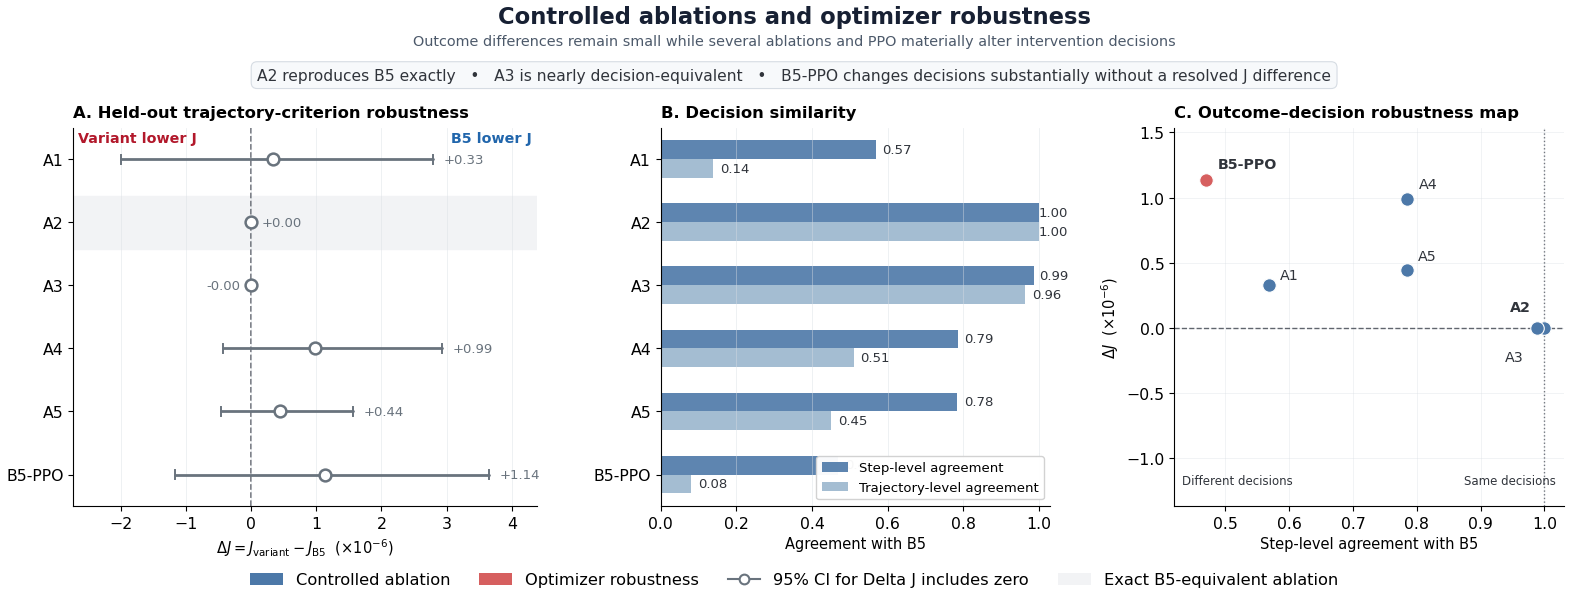

In [6]:
# =============================================================================
# Figure 5
# =============================================================================

data_fig5 = pd.read_csv("C:/Users/fredy/Downloads/CEUS_LILLE_DATA/figure_data/q1pp_v1_1_0/fig5_ablation_optimizer.csv")

d = data_fig5.copy()


# STRICT DATA AUDIT

required = [
    "split",
    "reference",
    "candidate",
    "delta_J",
    "J_ci_lo",
    "J_ci_hi",
    "step_action_agreement",
    "trajectory_action_agreement",
    "spec",
    "type"]

missing = [c for c in required if c not in d.columns]

expected_specs = {"A1", "A2", "A3", "A4", "A5", "B5_PPO"}

display_map = {
    "A1": "A1",
    "A2": "A2",
    "A3": "A3",
    "A4": "A4",
    "A5": "A5",
    "B5_PPO": "B5-PPO",
}

d["display"] = d["spec"].map(display_map)

order = ["A1", "A2", "A3", "A4", "A5", "B5_PPO"]

d = (d.set_index("spec").loc[order].reset_index())

d["display"] = d["spec"].map(display_map)

# Delta J = J_variant - J_B5
# positive => B5 has lower J
# negative => variant has lower J

d["resolved"] = ((d["J_ci_lo"] > 0) | (d["J_ci_hi"] < 0))

d["direction"] = np.select([d["J_ci_hi"] < 0, d["J_ci_lo"] > 0],["variant", "B5"], default="unresolved")

# Scale for readable units
scale = 1e6

d["delta_J_micro"] = scale * d["delta_J"]
d["J_ci_lo_micro"] = scale * d["J_ci_lo"]
d["J_ci_hi_micro"] = scale * d["J_ci_hi"]


mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12.5,
    "axes.titlesize": 11.8,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 11.3,
    "ytick.labelsize": 11.3,
})

# COLORS

ABLATION_COLOR = "#4C78A8"
PPO_COLOR = "#D65F5F"

B5_FAVOR_COLOR = "#2166AC"
VARIANT_FAVOR_COLOR = "#B2182B"
UNRESOLVED_COLOR = "#69737D"

A2_BAND = "#F2F3F5"

STEP_COLOR = "#4C78A8"
TRAJ_COLOR = "#9FBAD0"

GRID_COLOR = "#D9DEE3"
ZERO_COLOR = "#2F3540"
TEXT_COLOR = "#30343B"


# FIGURE LAYOUT

fig = plt.figure(figsize=(16.2, 6.2), facecolor="white")

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.25, 1.05, 1.05],
    left=0.055,
    right=0.975,
    bottom=0.18,
    top=0.79,
    wspace=0.30
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])


# =============================================================================
# PANEL A — OUTCOME ROBUSTNESS
# =============================================================================

y = np.arange(len(d))

# Highlight A2 because it is exactly identical to B5
a2_idx = list(d["spec"]).index("A2")

axA.axhspan(
    a2_idx - 0.42,
    a2_idx + 0.42,
    color=A2_BAND,
    zorder=0
)

axA.axvline(
    0,
    color=ZERO_COLOR,
    linestyle="--",
    linewidth=1.1,
    alpha=0.8,
    zorder=1
)

for i, row in d.iterrows():

    lo = float(row["J_ci_lo_micro"])
    est = float(row["delta_J_micro"])
    hi = float(row["J_ci_hi_micro"])

    if row["direction"] == "B5":
        color = B5_FAVOR_COLOR

    elif row["direction"] == "variant":
        color = VARIANT_FAVOR_COLOR

    else:
        color = UNRESOLVED_COLOR

    axA.plot(
        [lo, hi],
        [i, i],
        color=color,
        linewidth=2.0,
        solid_capstyle="round",
        zorder=3
    )

    cap = 0.075
    axA.plot([lo, lo], [i - cap, i + cap], color=color, linewidth=1.4, zorder=3)
    axA.plot([hi, hi], [i - cap, i + cap], color=color, linewidth=1.4, zorder=3)

    if row["resolved"]:
        axA.scatter(est, i, s=72, facecolor=color, edgecolor="white", linewidth=0.8, zorder=5)

    else:
        axA.scatter(est, i, s=72, facecolor="white", edgecolor=color, linewidth=1.8, zorder=5)

    # direct numeric annotation
    offset = 0.03 * (d["J_ci_hi_micro"].max()  - d["J_ci_lo_micro"].min())

    if est >= 0:
        tx = hi + offset
        ha = "left"

    else:
        tx = lo - offset
        ha = "right"

    axA.text(
        tx,
        i,
        f"{est:+.2f}",
        ha=ha,
        va="center",
        fontsize=9.5,
        color=color
    )


axA.set_yticks(y)
axA.set_yticklabels(d["display"])

axA.set_ylim(len(d) - 0.5, -0.5)

xlo = d["J_ci_lo_micro"].min()
xhi = d["J_ci_hi_micro"].max()

pad = 0.13 * (xhi - xlo)

axA.set_xlim(xlo - pad, xhi + pad)

axA.set_xlabel(
    r"$\Delta J = J_{\mathrm{variant}}-J_{\mathrm{B5}}$"
    r"  $(\times 10^{-6})$"
)

axA.set_title(
    "A. Held-out trajectory-criterion robustness",
    loc="left",
    fontweight="semibold",
    pad=8
)

axA.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.55,
    alpha=0.55
)

axA.text(
    0.01,
    0.955,
    "Variant lower J",
    transform=axA.transAxes,
    ha="left",
    va="bottom",
    fontsize=10.3,
    color=VARIANT_FAVOR_COLOR,
    fontweight="semibold"
)

axA.text(
    0.99,
    0.955,
    "B5 lower J",
    transform=axA.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.3,
    color=B5_FAVOR_COLOR,
    fontweight="semibold"
)


# =============================================================================
# PANEL B — DECISION AGREEMENT
# =============================================================================

bar_h = 0.30

axB.barh(
    y - bar_h / 2,
    d["step_action_agreement"],
    height=bar_h,
    color=STEP_COLOR,
    alpha=0.90,
    label="Step-level agreement"
)

axB.barh(
    y + bar_h / 2,
    d["trajectory_action_agreement"],
    height=bar_h,
    color=TRAJ_COLOR,
    alpha=0.95,
    label="Trajectory-level agreement"
)

axB.set_yticks(y)
axB.set_yticklabels(d["display"])

axB.set_ylim(len(d) - 0.5, -0.5)

axB.set_xlim(0, 1.03)

axB.set_xlabel("Agreement with B5")

axB.set_title(
    "B. Decision similarity",
    loc="left",
    fontweight="semibold",
    pad=8
)

axB.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.96,
    edgecolor="0.82",
    fontsize=9.5
)

axB.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.55,
    alpha=0.55
)

for i, row in d.iterrows():

    axB.text(
        min(float(row["step_action_agreement"]) + 0.018, 1.0),
        i - bar_h / 2,
        f"{float(row['step_action_agreement']):.2f}",
        va="center",
        ha="left",
        fontsize=9.5,
        color=TEXT_COLOR
    )

    axB.text(
        min(float(row["trajectory_action_agreement"]) + 0.018, 1.0),
        i + bar_h / 2,
        f"{float(row['trajectory_action_agreement']):.2f}",
        va="center",
        ha="left",
        fontsize=9.5,
        color=TEXT_COLOR
    )


# =============================================================================
# PANEL C — OUTCOME–DECISION MAP
# =============================================================================

for _, row in d.iterrows():

    color = (
        PPO_COLOR
        if row["type"] == "optimizer"
        else ABLATION_COLOR
    )

    axC.scatter(
        float(row["step_action_agreement"]),
        float(row["delta_J_micro"]),
        s=95,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        zorder=4
    )

    label_offsets = {
        "A1": (8, 2),
        "A2": (-10, 10),
        "A3": (-10, -16),
        "A4": (8, 6),
        "A5": (8, 5),
        "B5_PPO": (8, 6),
    }

    dx, dy = label_offsets[row["spec"]]

    ha = "left" if dx >= 0 else "right"
    va = "bottom" if dy >= 0 else "top"

    axC.annotate(
        row["display"],
        xy=(float(row["step_action_agreement"]), float(row["delta_J_micro"])),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        fontsize=10.3,
        color=TEXT_COLOR,
        fontweight=(
            "semibold"
            if row["spec"] in ["A2", "B5_PPO"]
            else "normal"
        ),
        zorder=6
    )


# reference axes
axC.axhline(
    0,
    color=ZERO_COLOR,
    linestyle="--",
    linewidth=1.0,
    alpha=0.75
)

axC.axvline(
    1,
    color=ZERO_COLOR,
    linestyle=":",
    linewidth=1.0,
    alpha=0.65
)

axC.set_xlim(0.42, 1.03)

y_abs = max(abs(d["delta_J_micro"].min()), abs(d["delta_J_micro"].max()))

axC.set_ylim(-1.20 * y_abs, 1.35 * y_abs)

axC.set_xlabel("Step-level agreement with B5")

axC.set_ylabel(r"$\Delta J$  $(\times 10^{-6})$")

axC.set_title(
    "C. Outcome–decision robustness map",
    loc="left",
    fontweight="semibold",
    pad=8
)

axC.grid(
    color=GRID_COLOR,
    linewidth=0.55,
    alpha=0.45
)

axC.text(
    0.98,
    0.05,
    "Same decisions",
    transform=axC.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5,
    color=TEXT_COLOR
)

axC.text(
    0.02,
    0.05,
    "Different decisions",
    transform=axC.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.5,
    color=TEXT_COLOR
)

for ax in [axA, axB, axC]:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out",
        length=3.5,
        width=0.8
    )

# =============================================================================

fig.suptitle(
    "Controlled ablations and optimizer robustness",
    y=0.988,
    fontsize=16.3,
    fontweight="bold",
    color="#172033"
)

fig.text(
    0.5,
    0.93,
    (
        "Outcome differences remain small while several ablations "
        "and PPO materially alter intervention decisions"
    ),
    ha="center",
    va="center",
    fontsize=10.4,
    color="#4C596A"
)


fig.text(
    0.5,
    0.875,
    (
        "A2 reproduces B5 exactly   •   "
        "A3 is nearly decision-equivalent   •   "
        "B5-PPO changes decisions substantially without a resolved J difference"
    ),
    ha="center",
    va="center",
    fontsize=11.2,
    color=TEXT_COLOR,
    bbox=dict(
        boxstyle="round,pad=0.38",
        facecolor="#F7F9FB",
        edgecolor="#D6DCE3",
        linewidth=0.8
    )
)


# =============================================================================
# GLOBAL LEGEND
# =============================================================================

legend_handles = [

    Patch(
        facecolor=ABLATION_COLOR,
        edgecolor="none",
        label="Controlled ablation"
    ),

    Patch(
        facecolor=PPO_COLOR,
        edgecolor="none",
        label="Optimizer robustness"
    ),

    Line2D(
        [0], [0],
        marker="o",
        color=UNRESOLVED_COLOR,
        markerfacecolor="white",
        markeredgecolor=UNRESOLVED_COLOR,
        markeredgewidth=1.5,
        linewidth=1.5,
        markersize=7,
        label="95% CI for Delta J includes zero"
    ),

    Patch(
        facecolor=A2_BAND,
        edgecolor="none",
        label="Exact B5-equivalent ablation"
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.025),
    ncol=4,
    frameon=False,
    fontsize=11.7,
    columnspacing=1.8
)

plt.show()
